In [46]:
import sys
import os
from pathlib import Path
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..", "rescomp", "rescomp")))
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..", "Thinned_Rescomp", "utils")))

from file_io import load_bundle_data_by_name, load_parameters
from paper_visualization import (
    configure_paper_style,
    plot_reservoir_response,
    plot_replica_pair,
    plot_replica_convergence,
    plot_reservoir_heatmap,
    plot_lorenz_attractor,
)
from reservoir_workflows import build_and_save_best_reservoir
import numpy as np

configure_paper_style()

### Compute and Save High VPT Matrices

In [47]:
# Load parameters from the configuration file
# Choose one of: 'paper_parameters', 'good_parameters', 'bad_parameters'
param_set_name = 'average_spectral_radius_good_vpt_good_diversity_good_consistency_parameters'
params = load_parameters(param_set_name)

# Unpack parameters
n = params['n']
network_type = params['network_type']
rho = params['rho']
mean_degree = params['mean_degree']
p = params['p']
alpha = params['alpha']
gamma = params['gamma']
sigma = params['sigma']
tol = params['tol']
duration = params['duration']
switch = params['switch']

# Save plots in ./plots/param_set_name relative to this notebook working directory
plots_dir = Path(f"plots/{param_set_name}")
plots_dir.mkdir(parents=True, exist_ok=True)

print(f"Loaded parameters: {params['description']}")
print(f"Saving plots to: {plots_dir.resolve()}")

Loaded parameters: Good Parameters from our work
Saving plots to: /home/dallin/Documents/Classes/Network_Theory/Thinned_Rescomp/paper_plots/plots/average_spectral_radius_good_vpt_good_diversity_good_consistency_parameters


In [48]:
build_and_save_best_reservoir(
    n,
    network_type,
    rho,
    mean_degree,
    alpha,
    gamma,
    sigma,
    tol,
    duration,
    switch,
    draw_count=100,
    vpt_upper_bound=3.5,
    skip_if_bundle_exists=True,
    override=False,
    parameter_set_name=param_set_name,
)

Bundle already exists at data/bundle_average_spectral_radius_good_vpt_good_diversity_good_consistency_parameters; skipping reservoir search.


In [49]:
A, initial_conditions, t_train, U_train, t_test, U_test, U_hat_train, U_hat_pred, states_train, states_pred, replica_states_1, replica_states_2, W_out, vpt = load_bundle_data_by_name(
    param_set_name
)

vpt = vpt[0]
reservoir_states = np.vstack((states_train, states_pred))
T = states_train.shape[0]
t = np.arange(reservoir_states.shape[0])
u_true = np.vstack((U_train[:-1], U_test))
u_hat = np.vstack((U_hat_train, U_hat_pred))

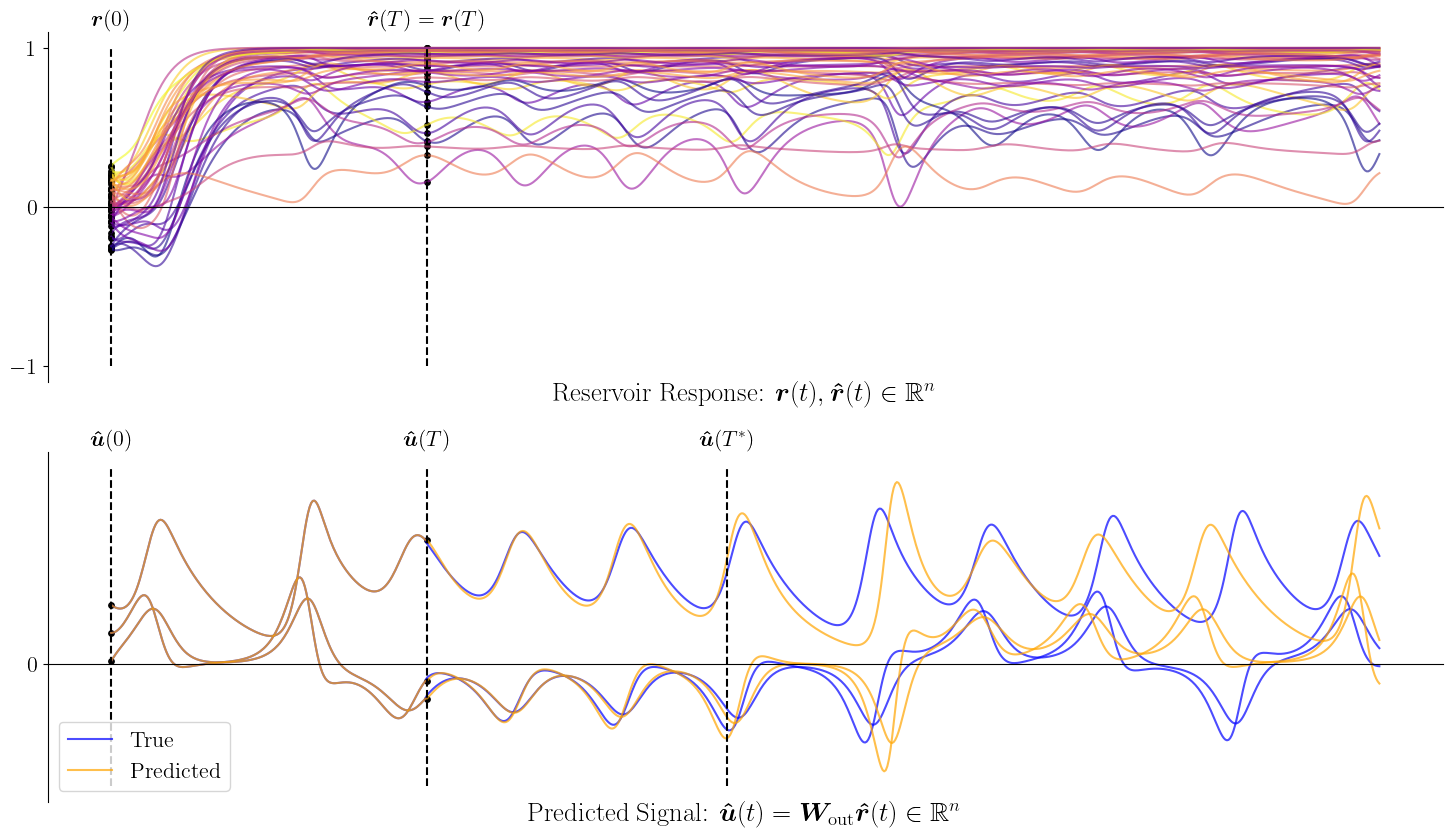

In [50]:
plot_reservoir_response(
    reservoir_states,
    u_true,
    u_hat,
    T,
    t,
    vpt,
    n,
    save_path=plots_dir / "response_signal.png",
    save_dpi=600,
)

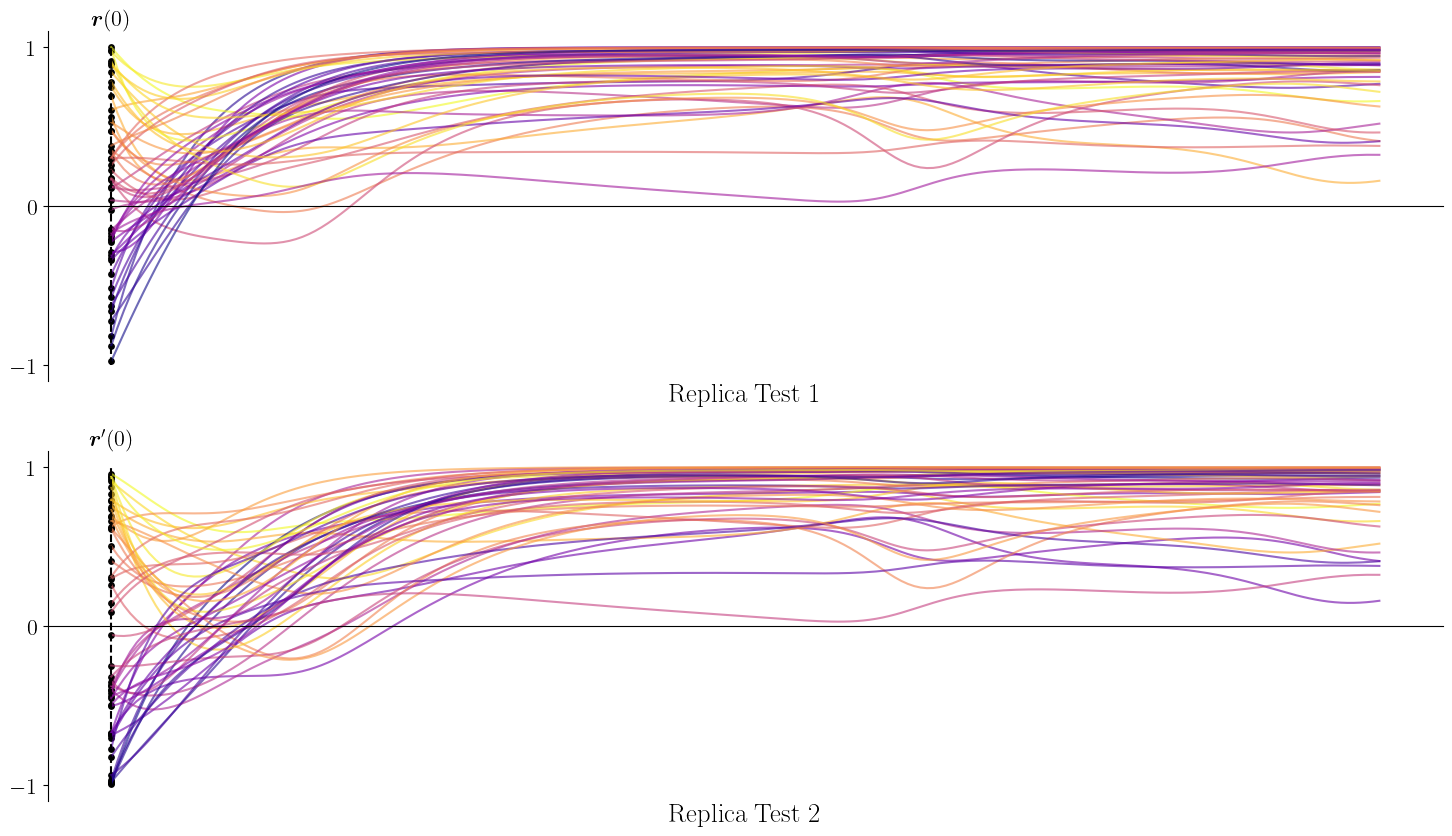

In [51]:
plot_replica_pair(
    replica_states_1,
    replica_states_2,
    t_train,
    n,
    save_path=plots_dir / "replica_pair.png",
    save_dpi=600,
)

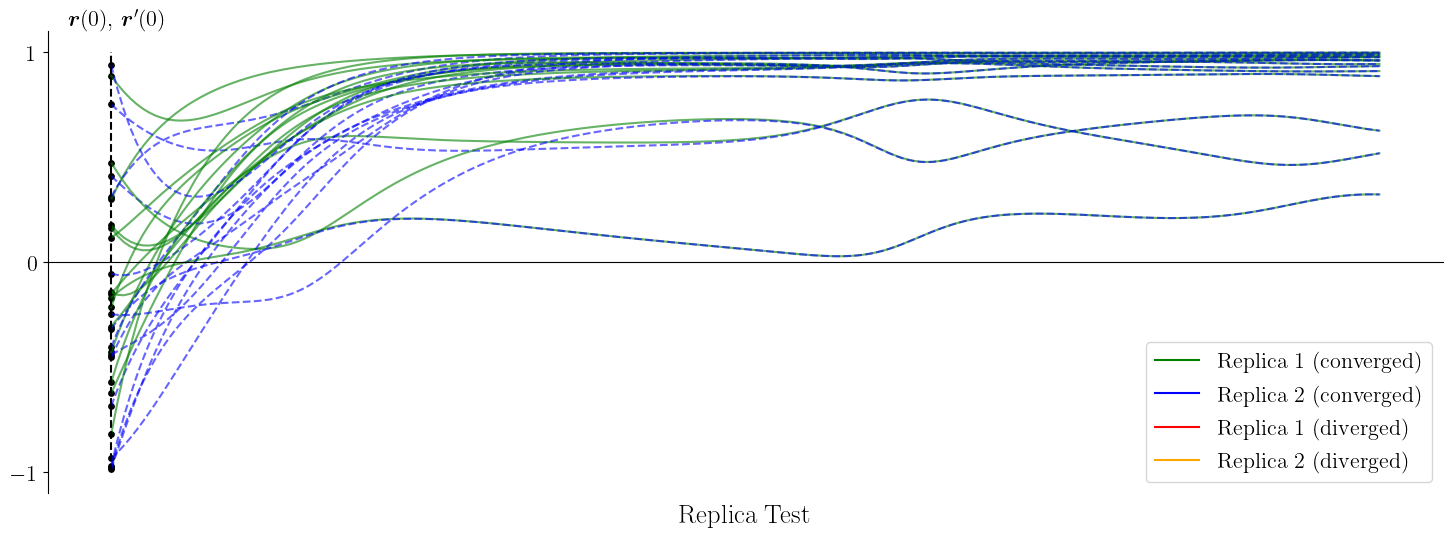

In [52]:
plot_replica_convergence(
    replica_states_1,
    replica_states_2,
    t_train,
    n,
    tail=50,
    conv_tol=1e-3,
    save_path=plots_dir / "replica_convergence.png",
    save_dpi=600,
)

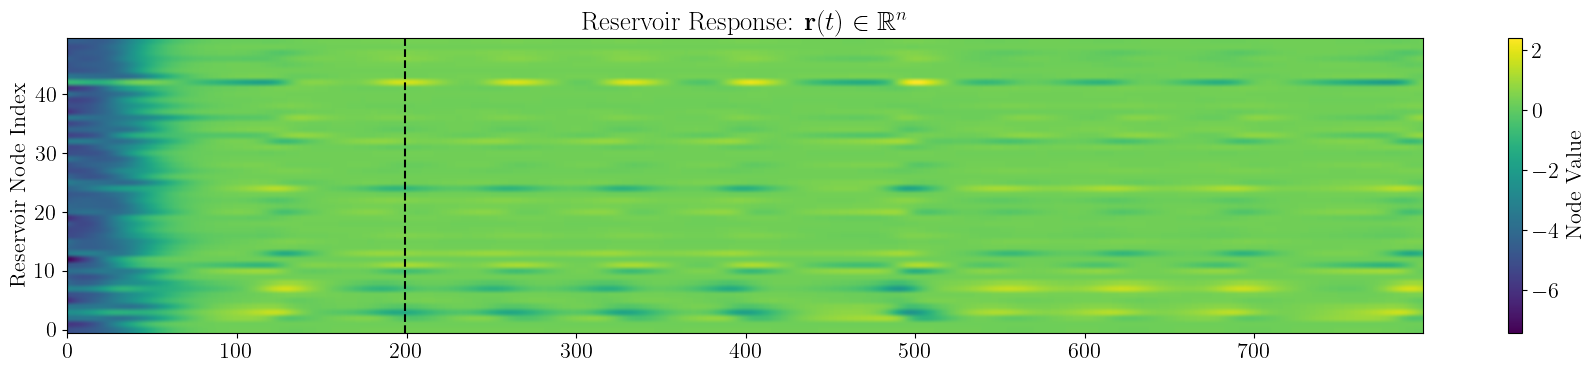

In [53]:
plot_reservoir_heatmap(
    reservoir_states,
    u_true,
    u_hat,
    T,
    t,
    save_path=plots_dir / "reservoir_heatmap.png",
    save_dpi=600,
)

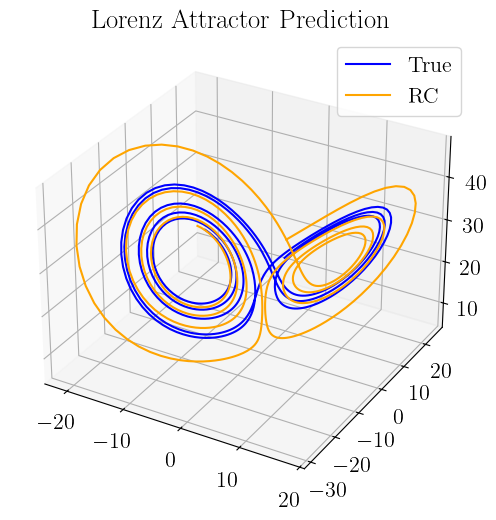

In [54]:
plot_lorenz_attractor(
    U_test,
    U_hat_pred,
    save_path=plots_dir / "lorenz_attractor.png",
    save_dpi=600,
)